In [1]:
from pathlib import Path

import mlflow
import pandas as pd

from countcv.effcv.plotting_pipeline import (
	MetricCol,
	ParamCol,
	aggregate_experiments_by_seed,
	init_plot_env,
	plot_line_with_uncertainty,
	plot_scatter,
	user_gpu_mapping,
)
# TODO !!! must be absolute -> adapt path !!!
mlruns_abs_path_leipzig = Path("/home/vossi/Dokumente/rotational_inv/hpc_output/leipzig/mlruns")
OUT_DIR = Path("../plots")

## Experiments Foci
### train_size and auto vs gt label

In [2]:
init_plot_env(mlruns_abs_path_leipzig, out_dir=OUT_DIR)
runs_train_size_gen = mlflow.search_runs(
		max_results=700,
		output_format="pandas",
		experiment_names=["foci_leipzig_yolo_train_size_generated"],
	)
assert isinstance(runs_train_size_gen, pd.DataFrame)
runs_train_size_gen[ParamCol.DATASET] = runs_train_size_gen[ParamCol.DATASET].map({"foci":"generated labels"})

init_plot_env(mlruns_abs_path_leipzig, out_dir=OUT_DIR)
# ! started experiment with incorrect experiment_name 
# ! -> solved by adding tags 'analyze' in mlflow ui
# ! tags exist not in the remote mlflow runs!
runs_train_size = mlflow.search_runs(
		filter_string="tags.analyze='train_size'",
		max_results=700,
		output_format="pandas",
		experiment_names=["foci_leipzig_yolo_model_size"],
	)
assert isinstance(runs_train_size, pd.DataFrame)
runs_train_size[ParamCol.DATASET] = runs_train_size[ParamCol.DATASET].map({"foci":"generated labels"})

runs_gt_train_size = mlflow.search_runs(
		filter_string="tags.analyze='gt_train_size'",
		max_results=700,
		output_format="pandas",
		experiment_names=["foci_leipzig_yolo_train_size"],
	)
assert isinstance(runs_gt_train_size, pd.DataFrame)
runs_gt_train_size[ParamCol.DATASET] = runs_gt_train_size[ParamCol.DATASET].map({"foci":"ground truth labels"})


In [3]:
runs_train_size_all = pd.concat([runs_train_size_gen, runs_gt_train_size, runs_train_size], ignore_index=True)
runs_train_size_all["params.batch_size"]="4" # some have different batch_size -> manipulate to allow aggregation for train_size comparison
runs_train_size_agg = aggregate_experiments_by_seed(runs_train_size_all)

Found 12 experiment groups (grouped by 22 params, excluding seed).

Group 1:
  Group key (params.* except seed):
    params.python_version: 3.12.3
    params.train_size: 100
    params.freeze: 0
    params.mosaic: 1.0
    params.hsv_s: 0.4
    params.num_worker: 4
    params.trainable_parameter: 0
    params.approach: objectdetection
    params.batch_size: 4
    params.epochs: 100
    params.Cuda version: 12.6
    params.patience: 8
    params.pretrained: True
    params.version: yolov8n.pt
    params.model_name: YOLOv8
    params.dataset_name: generated labels
    params.degree: 0.0
    params.translate: 0.0
    params.flipud: 0.3
    params.fliplr: 0.3
    params.img_size: nan
    tags.mlflow.user: tz51aquc
  Contains 16 runs with different seeds: ['9', '8', '7', '6', '5', '4', '3', '2', '1', '0']

Group 2:
  Group key (params.* except seed):
    params.python_version: 3.12.3
    params.train_size: 100
    params.freeze: 0
    params.mosaic: nan
    params.hsv_s: 0.4
    params.num_w

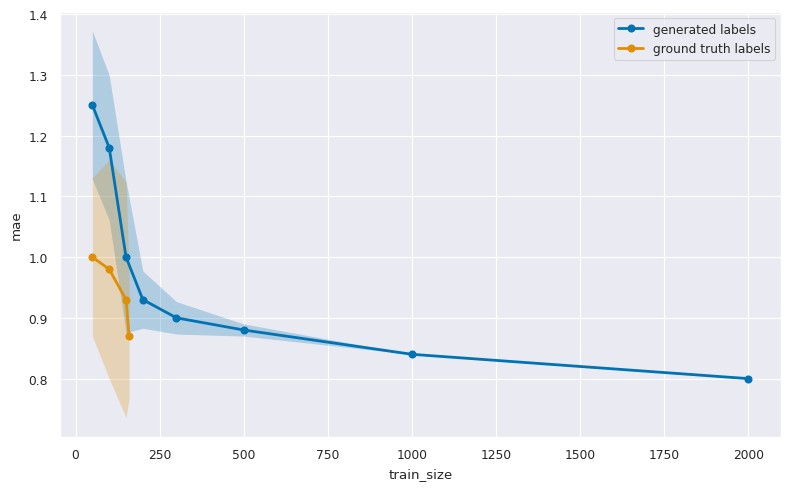

In [4]:
runs_train_size_agg[ParamCol.TRAIN_SIZE] = runs_train_size_agg[ParamCol.TRAIN_SIZE].astype(int)
runs_train_size_agg = runs_train_size_agg.sort_values(by=[ParamCol.TRAIN_SIZE])
runs_train_size_agg.to_csv("../plots/data_tag_der_forschung_train_size.csv")

runs_train_size_agg["metrics.mae"] = runs_train_size_agg["metrics.mae_mean"] # to use mean in plot instead median
plot_line_with_uncertainty(runs=runs_train_size_agg, y_col="metrics.mae", x_col=ParamCol.TRAIN_SIZE,hue_param=ParamCol.DATASET)

## Experiments with model_size and hardware
### datasets foci and carpk

In [5]:
init_plot_env(mlruns_abs_path_leipzig, OUT_DIR)
runs_leipzig = mlflow.search_runs(
		filter_string="tags.analyze='model_size'",
		max_results=700,
		output_format="pandas",
		experiment_names=["foci_leipzig_yolo_model_size","carpk_leipzig_yolo_model_size"],
	)
assert isinstance(runs_leipzig, pd.DataFrame)
runs_leipzig_cnn = mlflow.search_runs(
		filter_string="tags.analyze='model_size'",
		max_results=700,
		output_format="pandas",
		experiment_names=["tagderforschung"],
	)
assert isinstance(runs_leipzig_cnn, pd.DataFrame)
runs_leipzig_cnn[MetricCol.MAE] = runs_leipzig_cnn["metrics.best_mae"]
runs_leipzig_yolo11 = mlflow.search_runs(
    max_results=700,
	output_format="pandas",
	experiment_names=["foci_leipzig_yolo11_model_size","carpk_leipzig_yolo11_model_size"]
)
assert isinstance(runs_leipzig_yolo11, pd.DataFrame)
mlflow_dresden_path = Path("/home/vossi/Dokumente/rotational_inv/hpc_output/dresden/mlruns")
init_plot_env(mlrun_abs_path=mlflow_dresden_path, out_dir=OUT_DIR)
runs_dresden = mlflow.search_runs(
    max_results=700,
	output_format="pandas",
	experiment_names=["foci_dresden_yolo_model_size","carpk_dresden_yolo_model_size","carpk_dresden_yolo_model_size_v11"]
)
assert isinstance(runs_dresden, pd.DataFrame)
mlflow_local_path = Path("/home/vossi/Dokumente/rotational_inv/rotationally-invariant-cnns/mlruns")
init_plot_env(mlflow_local_path, out_dir=OUT_DIR)
runs_local_carpk = mlflow.search_runs(
    filter_string="params.train_size='500'",
    max_results=700,
    output_format="pandas",
    experiment_names=["carpk_train_size_yolo_local_iv", "carpk_model_size_yolo_local_iv"]
)
assert isinstance(runs_local_carpk, pd.DataFrame)
runs_local_foci = mlflow.search_runs(
    filter_string="",
    max_results=700,
    output_format="pandas",
    experiment_names=["foci_yolo"]
)
assert isinstance(runs_local_foci, pd.DataFrame)
runs_local_cnn = mlflow.search_runs(
    filter_string="",
    max_results=700,
    output_format="pandas",
    experiment_names=["tagderforschung"]
)
assert isinstance(runs_local_foci, pd.DataFrame)
runs_local_cnn["metrics.mae"]=runs_local_cnn["metrics.best_mae"] # in density maps the mae was set by last not best model

In [6]:
print(runs_leipzig.shape)
print(runs_dresden.shape)
print(runs_local_carpk.shape)
print(runs_local_foci.shape)
print(runs_local_cnn.shape)

(70, 62)
(110, 62)
(41, 58)
(48, 61)
(40, 53)


In [7]:
# merge runs
runs = pd.concat([runs_dresden, runs_leipzig, runs_leipzig_yolo11, runs_local_carpk, runs_local_foci, runs_leipzig_cnn, runs_local_cnn], ignore_index=True)
runs["tags.mlflow.user"] = runs["tags.mlflow.user"].map(user_gpu_mapping)

In [8]:
runs_agg = aggregate_experiments_by_seed(runs, verbose=False)
runs_agg["params.version"] = runs_agg["params.version"].apply(lambda x: str(x).replace(".pt","",))
runs_agg["metrics.energy_joule"] = runs_agg["metrics.energy_joule"]/1000
runs_agg.rename(columns={"metrics.energy_joule":"Energy [kJ]", "tags.mlflow.user": "GPU", ParamCol.DATASET:"Dataset"}, inplace=True)

In [9]:
# add model as categorical to allow custom ordering in scatter plot
custom_order = ["yolov8n","yolov8s","yolov8m","yolov8l", "yolo11n","yolo11s","yolo11m","yolo11l", "fcrn-base","SAUnet"]
runs_agg["params.version"] = pd.Categorical(runs_agg["params.version"], categories=custom_order, ordered=True)
runs_agg = runs_agg.sort_values(by=[ParamCol.MODEL_VERSION],ascending=True)

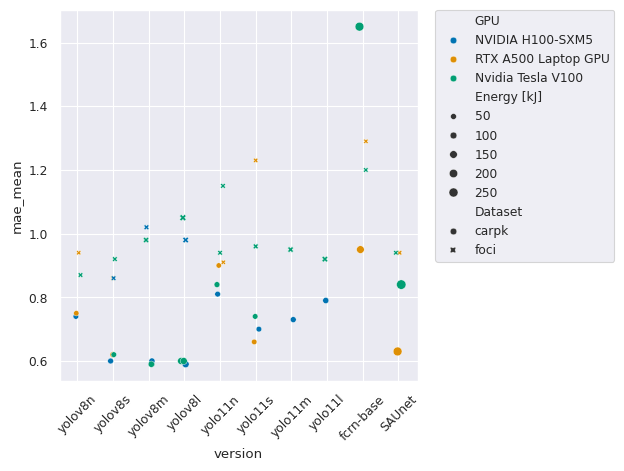

In [10]:
plot_scatter(runs=runs_agg, x_col="params.version",size_param="Energy [kJ]", y_col="metrics.mae_mean", hue_param="GPU", symbol_param="Dataset", show=True)

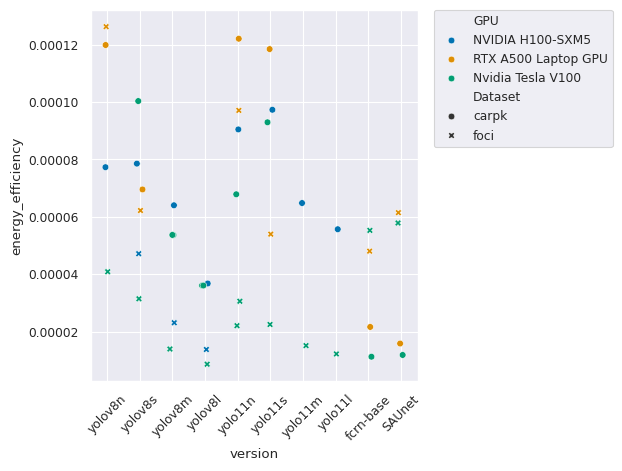

In [54]:
plot_scatter(runs=runs_agg, x_col=ParamCol.MODEL_VERSION, y_col=MetricCol.ENERGY_EFFICIENCY, hue_param="GPU", symbol_param="Dataset", show=True)

In [14]:
for col in runs_agg.columns:
    print(col)

run_id
experiment_id
status
artifact_uri
start_time
end_time
metrics.error_variance
metrics.val_mean_iou
metrics.metrics/mAP50_B_
metrics.train/cls_loss
metrics.metrics/recall_B_
metrics.train/dfl_loss
metrics.mape
metrics.energy_gpu
metrics.val_map
metrics.early_stopped_at_epoch
metrics.val/box_loss
metrics.metrics/mAP50-95_B_
metrics.mae
metrics.lr/pg2
metrics.duration_sec
metrics.lr/pg0
metrics.time
metrics.energy_cpu
metrics.entropy_gain
metrics.mean_count
metrics.lr/pg1
metrics.val/dfl_loss
metrics.train/box_loss
Energy [kJ]
metrics.mean_error
metrics.val/cls_loss
metrics.metrics/precision_B_
metrics.energy_efficiency
params.python_version
params.train_size
params.data_yaml
params.freeze
params.num_worker
params.seed
params.trainable_parameter
params.approach
params.batch_size
params.epochs
params.Cuda version
params.path
params.patience
params.pretrained
params.version
params.model_name
Dataset
params.img_size
params.fliplr
params.degrees
params.translate
params.flipud
params.hsv

In [49]:
runs_agg_rel = runs_agg[[ParamCol.MODEL_VERSION,ParamCol.TRAIN_SIZE,"Dataset", "GPU",MetricCol.DURATION_SEC,MetricCol.ENERGY_EFFICIENCY, "Energy [kJ]",MetricCol.ENERGY_GPU,MetricCol.ENERGY_CPU,MetricCol.ENTROPY_GAIN,"metrics.mae_mean",MetricCol.MEAN_ERROR,f"{MetricCol.DURATION_SEC.value}_var",f"{MetricCol.ENERGY_EFFICIENCY.value}_var", f"{MetricCol.ENERGY_JOULE.value}_var",f"{MetricCol.ENERGY_GPU.value}_var",f"{MetricCol.ENERGY_CPU.value}_var",f"{MetricCol.ENTROPY_GAIN.value}_var",f"{MetricCol.MAE.value}_var",f"{MetricCol.MEAN_ERROR.value}_var"]]

In [138]:
runs_agg_renamed = runs_agg_rel.rename(columns={"params.version":"Model","params.train_size":"Train Images","metrics.duration_sec":"Duration [s]","metrics.energy_efficiency":"Efficiency","metrics.energy_gpu":"Energy GPU [kJ]","metrics.energy_cpu":"Energy CPU [J]","metrics.entropy_gain":"Entropy Gain","metrics.mae_mean":"MAE mean","metrics.mean_error":"mean error","metrics.duration_sec_var":"Duration [s] std"	,"metrics.energy_efficiency_var":"Efficiency std","metrics.energy_joule_var":"Energy [kJ] std","metrics.mae_var":"MAE std"})
runs_agg_renamed = runs_agg_renamed.drop(columns=["Train Images",f"{MetricCol.ENERGY_GPU.value}_var",f"{MetricCol.ENERGY_CPU.value}_var",f"{MetricCol.ENTROPY_GAIN.value}_var",f"{MetricCol.MEAN_ERROR.value}_var"])

In [ ]:
runs_agg_renamed.style

In [ ]:
def pandas_df_to_markdown_table(df):
    from IPython.display import Markdown, display
    fmt = ['---' for i in range(len(df.columns))]
    df_fmt = pd.DataFrame([fmt], columns=df.columns)
    df_formatted = pd.concat([df_fmt, df])
    display(Markdown(df_formatted.to_csv(sep="|", index=False)))

pandas_df_to_markdown_table(runs_agg_renamed)

In [139]:
# does not fit on landscape page -> drop cols
runs_agg_renamed["Energy GPU [kJ]"] = runs_agg_renamed["Energy GPU [kJ]"]/1000
runs_agg_renamed["Efficiency"]=runs_agg_renamed["Efficiency"]*1000
runs_agg_renamed["Energy [kJ] std"]=runs_agg_renamed["Energy [kJ] std"]/1000
runs_agg_carpk = runs_agg_renamed[runs_agg_renamed["Dataset"]=="carpk"].drop(columns=["Dataset","Energy CPU [J]","Entropy Gain","Efficiency std","mean error"])
runs_agg_foci = runs_agg_renamed[runs_agg_renamed["Dataset"]=="foci"].drop(columns=["Dataset","Energy CPU [J]","Entropy Gain","Efficiency std","mean error"])

In [79]:
print(len(runs_agg_carpk.columns))

13


In [140]:
runs_agg_carpk

,Model,GPU,Duration [s],Efficiency,Energy [kJ],Energy GPU [kJ],MAE mean,Duration [s] std,Energy [kJ] std,MAE std
36,yolov8n,NVIDIA H100-SXM5,156.752520,0.077291,37.241921,25.862837,0.74,63.892961,15.043872,0.142134
22,yolov8n,RTX A500 Laptop GPU,502.246795,0.119855,28.331225,14.475837,0.75,127.526398,7.383397,0.129967
23,yolov8s,RTX A500 Laptop GPU,847.803310,0.069539,47.865822,24.878105,0.62,291.001988,17.089158,0.075219
37,yolov8s,NVIDIA H100-SXM5,184.884815,0.078536,49.370352,34.924898,0.60,53.096854,13.687985,0.121297
38,yolov8s,Nvidia Tesla V100,326.200675,0.100329,37.655540,25.647989,0.62,96.485600,11.705640,0.087228
33,yolov8m,Nvidia Tesla V100,486.419525,0.053661,72.011384,53.654134,0.59,199.940914,30.651526,0.130596
34,yolov8m,NVIDIA H100-SXM5,194.414890,0.064029,61.464337,46.263051,0.60,70.577042,23.219321,0.090263
35,yolov8m,Nvidia Tesla V100,495.981885,0.053695,72.860935,54.460973,0.59,196.143234,30.364890,0.130596
32,yolov8l,Nvidia Tesla V100,625.944795,0.036085,108.320885,85.258689,0.60,180.122343,32.405214,0.113349
31,yolov8l,NVIDIA H100-SXM5,313.301015,0.036781,109.681044,85.530369,0.59,82.008644,30.339561,0.113500


In [141]:
column_format = "l" + "c" * (runs_agg_renamed.shape[1] - 1)

latex_table_carpk = runs_agg_carpk.to_latex(
    index=False,
    caption="Comparison of Performance and energy Metrics for carpk dataset",
    label="tab:model_comparison_carpk",
    column_format=column_format,
    escape=False,
    float_format="{:0.2f}".format,
)
latex_table_foci = runs_agg_foci.to_latex(
    index=False, 
    caption="Comparison of Performance and energy Metrics for foci dataset", 
    label="tab:model_comparison_foci",  # A label used for referencing the table within the LaTeX document
    column_format=column_format,  # The format of the columns: left-aligend first column and center-aligned remaining columns as per APA guidelines
    escape=False,  # Disable escaping LaTeX special characters in the DataFrame
    float_format="{:0.2f}".format  # Formats floats to two decimal places
)
#print(latex_table_foci)
print(latex_table_carpk)

\begin{table}
\caption{Comparison of Performance and energy Metrics for carpk dataset}
\label{tab:model_comparison_carpk}
\begin{tabular}{lcccccccccccccc}
\toprule
Model & GPU & Duration [s] & Efficiency & Energy [kJ] & Energy GPU [kJ] & MAE mean & Duration [s] std & Energy [kJ] std & MAE std \\
\midrule
yolov8n & NVIDIA H100-SXM5 & 156.75 & 0.08 & 37.24 & 25.86 & 0.74 & 63.89 & 15.04 & 0.14 \\
yolov8n & RTX A500 Laptop GPU & 502.25 & 0.12 & 28.33 & 14.48 & 0.75 & 127.53 & 7.38 & 0.13 \\
yolov8s & RTX A500 Laptop GPU & 847.80 & 0.07 & 47.87 & 24.88 & 0.62 & 291.00 & 17.09 & 0.08 \\
yolov8s & NVIDIA H100-SXM5 & 184.88 & 0.08 & 49.37 & 34.92 & 0.60 & 53.10 & 13.69 & 0.12 \\
yolov8s & Nvidia Tesla V100 & 326.20 & 0.10 & 37.66 & 25.65 & 0.62 & 96.49 & 11.71 & 0.09 \\
yolov8m & Nvidia Tesla V100 & 486.42 & 0.05 & 72.01 & 53.65 & 0.59 & 199.94 & 30.65 & 0.13 \\
yolov8m & NVIDIA H100-SXM5 & 194.41 & 0.06 & 61.46 & 46.26 & 0.60 & 70.58 & 23.22 & 0.09 \\
yolov8m & Nvidia Tesla V100 & 495.98 & 0

In [142]:
print(latex_table_foci)

\begin{table}
\caption{Comparison of Performance and energy Metrics for foci dataset}
\label{tab:model_comparison_foci}
\begin{tabular}{lcccccccccccccc}
\toprule
Model & GPU & Duration [s] & Efficiency & Energy [kJ] & Energy GPU [kJ] & MAE mean & Duration [s] std & Energy [kJ] std & MAE std \\
\midrule
yolov8n & RTX A500 Laptop GPU & 126.57 & 0.13 & 7.04 & 3.60 & 0.94 & 40.37 & 2.29 & 0.22 \\
yolov8n & Nvidia Tesla V100 & 216.93 & 0.04 & 23.45 & 15.49 & 0.87 & 27.81 & 3.07 & 0.10 \\
yolov8s & RTX A500 Laptop GPU & 311.86 & 0.06 & 18.20 & 8.54 & 0.86 & 82.37 & 4.73 & 0.16 \\
yolov8s & NVIDIA H100-SXM5 & 82.01 & 0.05 & 22.72 & 16.78 & 0.86 & 17.45 & 5.05 & 0.14 \\
yolov8s & Nvidia Tesla V100 & 217.25 & 0.03 & 25.75 & 17.78 & 0.92 & 52.76 & 6.55 & 0.12 \\
yolov8m & RTX A500 Laptop GPU & 8.84 & NaN & 0.41 & 0.16 & NaN & 2.13 & 0.11 & NaN \\
yolov8m & NVIDIA H100-SXM5 & 106.42 & 0.02 & 33.02 & 25.32 & 1.02 & 17.06 & 5.75 & 0.20 \\
yolov8m & Nvidia Tesla V100 & 393.89 & 0.01 & 58.08 & 43.62 

In [ ]:
import pandas as pd
import numbers
from typing import Optional

def df_to_latex_onepage(
    df: pd.DataFrame,
    caption: str = "",
    label: str = "",
    rotate_if_wide: bool = True,
    index_name: Optional[str] = None,
    small_number_scientific_threshold: float = 1e-2,
) -> str:
    """
    Convert a pandas DataFrame to a LaTeX table that fits on a single page.

    - Rotates the table (sidewaystable) if many columns.
    - Uses tabularimport pandas as pd
import numbers

def df_to_latex_onepage(
    df: pd.DataFrame,
    caption: str = "",
    label: str = "",
    rotate_if_wide: bool = True,
    index_name: str | None = None,
) -> str:
    """
    Convert a pandas DataFrame to a LaTeX table that fits on a single page.
    All numeric values (except the index column) are rounded to 2 decimals.
    """

    def _escape_latex(x) -> str:
        """Escape LaTeX special characters in a string."""
        s = str(x)
        repl = {
            "\\": r"\textbackslash{}",
            "&": r"\&",
            "%": r"\%",
            "$": r"\$",
            "#": r"\#",
            "_": r"\_",
            "{": r"\{",
            "}": r"\}",
            "~": r"\textasciitilde{}",
            "^": r"\textasciicircum{}",
        }
        for k, v in repl.items():
            s = s.replace(k, v)
        return s

    # Put the index into a proper column so it shows in the table
    df_show = df.copy()
    if index_name is None:
        index_name = df_show.index.name if df_show.index.name is not None else ""
    df_show.insert(0, index_name, df_show.index)
    df_show = df_show.reset_index(drop=True)

    n_cols = df_show.shape[1]

    # Heuristic: if many columns, rotate the table
    wide_threshold = 8
    use_sideways = rotate_if_wide and n_cols > wide_threshold

    env = "sidewaystable" if use_sideways else "table"
    box_width = r"\textheight" if use_sideways else r"\textwidth"

    # Column alignment: left-aligned for all columns
    col_format = "l" * n_cols

    # Header row
    header_cells = [_escape_latex(c) for c in df_show.columns]
    header = " & ".join(header_cells) + r" \\"

    # Data rows: rimport pandas as pd
import numbers

def df_to_latex_onepage(
    df: pd.DataFrame,
    caption: str = "",
    label: str = "",
    rotate_if_wide: bool = True,
    index_name: str | None = None,
) -> str:
    """
    Convert a pandas DataFrame to a LaTeX table that fits on a single page.
    All numeric values (except the index column) are rounded to 2 decimals.
    """

    def _escape_latex(x) -> str:
        """Escape LaTeX special characters in a string."""
        s = str(x)
        repl = {
            "\\": r"\textbackslash{}",
            "&": r"\&",
            "%": r"\%",
            "$": r"\$",
            "#": r"\#",
            "_": r"\_",
            "{": r"\{",
            "}": r"\}",
            "~": r"\textasciitilde{}",
            "^": r"\textasciicircum{}",
        }
        for k, v in repl.items():
            s = s.replace(k, v)
        return s

    # Put the index into a proper column so it shows in the table
    df_show = df.copy()
    if index_name is None:
        index_name = df_show.index.name if df_show.index.name is not None else ""
    df_show.insert(0, index_name, df_show.index)
    df_show = df_show.reset_index(drop=True)

    n_cols = df_show.shape[1]

    # Heuristic: if many columns, rotate the table
    wide_threshold = 8
    use_sideways = rotate_if_wide and n_cols > wide_threshold

    env = "sidewaystable" if use_sideways else "table"
    box_width = r"\textheight" if use_sideways else r"\textwidth"

    # Column alignment: left-aligned for all columns
    col_format = "l" * n_cols

    # Header row
    header_cells = [_escape_latex(c) for c in df_show.columns]
    header = " & ".join(header_cells) + r" \\"

    # Data rows: round numeric values (except first/index column) to 2 decimals
    row_lines = []
    for _, row in df_show.iterrows():
        cells = []
        for j, v in enumerate(row):
            if j == 0:
                # index column: keep as-is (no forced decimals)
                s = str(v)
            else:
                if isinstance(v, numbers.Number) and not isinstance(v, bool):
                    if pd.isna(v):
                        s = ""
                    else:
                        s = f"{v:.2f}"
                else:
                    s = str(v)
            cells.append(_escape_latex(s))
        row_lines.append(" & ".join(cells) + r" \\")
    body = "\n".join(row_lines)

    latex = rf"""
\begin{{{env}}}[htbp]
    \centering
    \caption{{{_escape_latex(caption)}}}
    \label{{{_escape_latex(label)}}}
    \begin{{adjustbox}}{{width={box_width}}}
        \begin{{tabular}}{{{col_format}}}
            \toprule
            {header}
            \midrule
            {body}
            \bottomrule
        \end{{tabular}}
    \end{{adjustbox}}
\end{{{env}}}
""".strip("\n")

    return latex
ound numeric values (except first/index column) to 2 decimals
    row_lines = []
    for _, row in df_show.iterrows():
        cells = []
        for j, v in enumerate(row):
            if j == 0:
                # index column: keep as-is (no forced decimals)
                s = str(v)
            else:
                if isinstance(v, numbers.Number) and not isinstance(v, bool):
                    if pd.isna(v):
                        s = ""
                    else:
                        s = f"{v:.2f}"
                else:
                    s = str(v)
            cells.append(_escape_latex(s))
        row_lines.append(" & ".join(cells) + r" \\")
    body = "\n".join(row_lines)

    latex = rf"""
\begin{{{env}}}[htbp]
    \centering
    \caption{{{_escape_latex(caption)}}}
    \label{{{_escape_latex(label)}}}
    \begin{{adjustbox}}{{width={box_width}}}
        \begin{{tabular}}{{{col_format}}}
            \toprule
            {header}
            \midrule
            {body}
            \bottomrule
        \end{{tabular}}
    \end{{adjustbox}}
\end{{{env}}}
""".strip("\n")

    return latex
x with automatic column width adjustment and wrapping
      for non-numeric columns (e.g. GPU).
    - Rounds numbers to 2 decimals.
    - Very small numbers (|x| < small_number_scientific_threshold)
      are printed in scientific notation x.xx×10^{n}.
    """

    def _escape_latex(x) -> str:
        s = str(x)
        repl = {
            "\\": r"\textbackslash{}",
            "&": r"\&",
            "%": r"\%",
            "$": r"\$",
            "#": r"\#",
            "_": r"\_",
            "{": r"\{",
            "}": r"\}",
            "~": r"\textasciitilde{}",
            "^": r"\textasciicircum{}",
        }
        for k, v in repl.items():
            s = s.replace(k, v)
        return s

    def _format_number(v: float) -> str:
        """Two decimals; small numbers in scientific notation."""
        if pd.isna(v):
            return ""
        if v == 0:
            return "0.00"
        av = abs(v)
        if av < small_number_scientific_threshold or av >= 1e4:
            # scientific notation
            s = f"{v:.2e}"  # e.g. '-1.23e-04'
            mant, exp = s.split("e")
            exp = int(exp)  # remove leading +0
            # 1.23×10^{-4}
            return rf"{mant}\times 10^{{{exp}}}"
        else:
            return f"{v:.2f}"

    # Copy and bring index into the table
    df_show = df.copy()
    if index_name is None:
        index_name = df_show.index.name if df_show.index.name is not None else ""
    df_show.insert(0, index_name, df_show.index)
    df_show = df_show.reset_index(drop=True)

    n_cols = df_show.shape[1]

    # Rotate if wide
    wide_threshold = 8
    use_sideways = rotate_if_wide and n_cols > wide_threshold

    env = "sidewaystable" if use_sideways else "table"
    width_arg = r"\textheight" if use_sideways else r"\textwidth"

    # Column spec for tabularx:
    # - first column (index): left
    # - object/categorical columns: X (wrapping, flexible width)
    # - numeric columns: r (right-aligned)
    col_specs = ["l"]  # for the inserted index column
    for col in df_show.columns[1:]:
        series = df_show[col]
        if pd.api.types.is_numeric_dtype(series):
            col_specs.append("r")
        else:
            col_specs.append("X")
    col_format = "".join(col_specs)

    # Build header
    header_cells = [_escape_latex(c) for c in df_show.columns]
    header = " & ".join(header_cells) + r" \\"

    # Build body with formatting
    row_lines = []
    for _, row in df_show.iterrows():
        cells = []
        for j, v in enumerate(row):
            if j == 0:
                # index column: no special numeric formatting
                s = str(v)
            else:
                if isinstance(v, numbers.Number) and not isinstance(v, bool):
                    s = _format_number(float(v))
                else:
                    s = str(v)
            cells.append(_escape_latex(s))
        row_lines.append(" & ".join(cells) + r" \\")
    body = "\n".join(row_lines)

    # LaTeX code using tabularx + small font
    latex = rf"""
\begin{{{env}}}[htbp]
    \centering
    \scriptsize
    \caption{{{_escape_latex(caption)}}}
    \label{{{_escape_latex(label)}}}
    \begin{{tabularx}}{{{width_arg}}}{{{col_format}}}
        \toprule
        {header}
        \midrule
        {body}
        \bottomrule
    \end{{tabularx}}
\end{{{env}}}
""".strip("\n")

    return latex


## mae vs energy plot
- did not used in 'Tag der Forschung' (too many plot, not enough time)
- all model sizes, two datasets (carpk, foci)
- only for *Laptop GPU* to increase comprehensibility

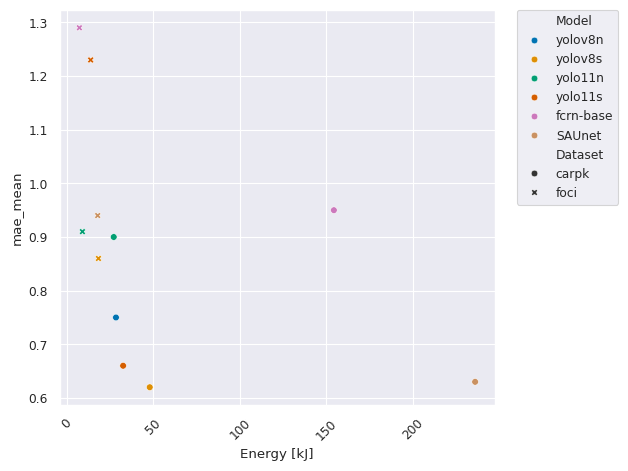

In [49]:
runs_agg_filtered = runs_agg.copy()
runs_agg_filtered["Model"] = runs_agg_filtered["params.version"].astype(str)
runs_agg_filtered = runs_agg_filtered[runs_agg_filtered["GPU"] == "RTX A500 Laptop GPU"]
runs_agg_filtered=runs_agg_filtered.dropna(subset=["metrics.mae"])
runs_agg_filtered.sort_values(by=["params.version","Dataset"], ascending=[True,False], inplace=True)
plot_scatter(runs=runs_agg_filtered, x_col="Energy [kJ]", y_col="metrics.mae_mean", hue_param="Model", symbol_param="Dataset", show=True)